In [23]:
import requests
import pandas as pd

In [24]:
print("Hello world")

Hello world


In [25]:
def get_historic_price(symbol, after='2018-09-01'):
    
    url = 'https://api.kraken.com/0/public/OHLC'
    pair = f"{symbol.upper()}USD" # XBTUSD when symbol='xbt' for example
    
    resp = requests.get(url, params={
        "pair": pair,
        'interval': 60,
        'since': str(int(pd.Timestamp(after).timestamp()))
    })
    resp.raise_for_status()
    
    data = resp.json()
    
    results_key = [k for k in data['result'].keys() if k != 'last'][0]
    results = [
        (close_time, float(open), float(high), float(low), float(close), float(volume))
        for (close_time, open, high, low, close, vwap, volume, count)
        in data['result'][results_key]
    ]
    df = pd.DataFrame(results, columns=[
        'CloseTime', 'OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice', 'Volume'
    ])
    df['CloseTime'] = pd.to_datetime(df['CloseTime'], unit='s')
    df.set_index('CloseTime', inplace=True)
    return df

In [26]:
last_week = (pd.Timestamp.now() - pd.offsets.Day(7))
last_week

Timestamp('2026-04-29 22:27:29.494535')

In [27]:
btc = get_historic_price('btc', after=last_week)

In [28]:
eth = get_historic_price('eth', after=last_week)

In [29]:
btc.describe()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
count,167.000000,167.000000,167.000000,167.000000,167.000000
mean,78934.169461,79140.168263,78771.283832,78967.635928,69.467032
std,1843.249164,1858.039447,1813.863847,1838.252126,66.811698
min,75463.200000,75717.300000,75290.900000,75463.200000,5.092645
25%,78148.900000,78218.600000,78043.300000,78156.350000,25.724796
50%,78649.300000,78765.000000,78435.000000,78652.400000,44.618114
75%,80553.950000,80864.400000,80488.650000,80677.900000,88.766607
max,82502.200000,82790.900000,82276.700000,82502.100000,314.155856


In [30]:
btc.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-04-29 23:00:00,75912.4,75960.0,75689.0,75750.3,40.141935
2026-04-30 00:00:00,75752.7,76301.5,75650.0,76244.0,67.197250
2026-04-30 01:00:00,76244.1,76413.8,76159.8,76197.8,28.946669
2026-04-30 02:00:00,76197.8,76324.9,75484.5,75685.9,36.413234
2026-04-30 03:00:00,75674.9,75956.7,75645.8,75918.8,11.305595


In [31]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 167 entries, 2026-04-29 23:00:00 to 2026-05-06 21:00:00
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OpenPrice   167 non-null    float64
 1   HighPrice   167 non-null    float64
 2   LowPrice    167 non-null    float64
 3   ClosePrice  167 non-null    float64
 4   Volume      167 non-null    float64
dtypes: float64(5)
memory usage: 7.8 KB


<Axes: xlabel='CloseTime'>

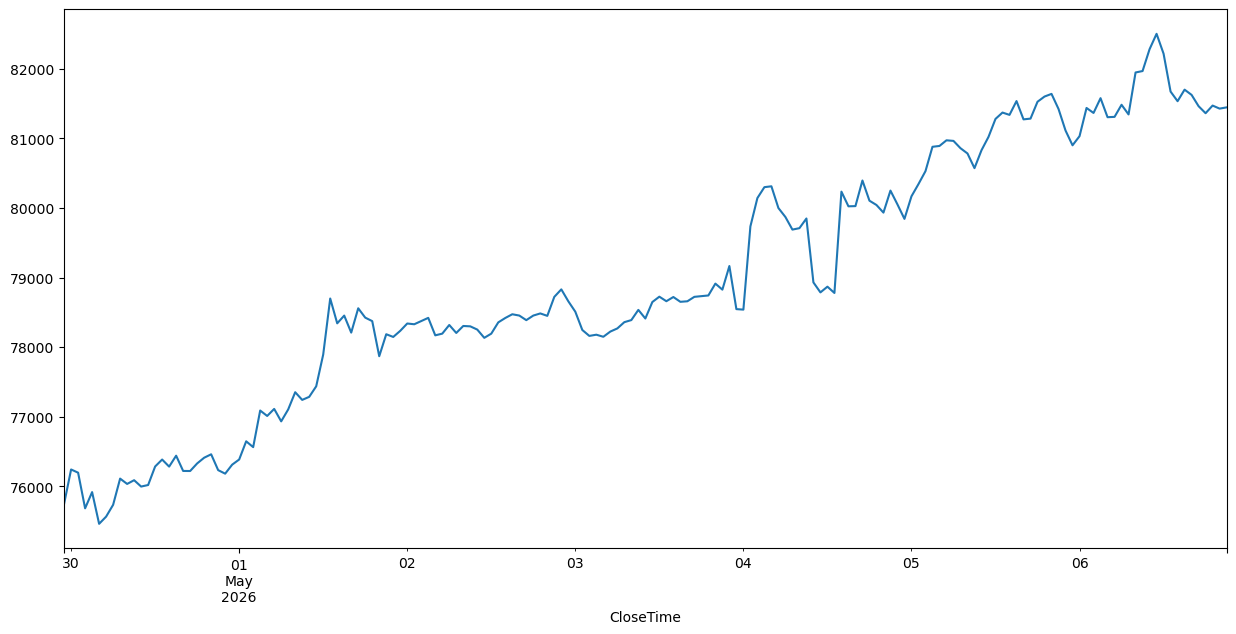

In [32]:
btc['ClosePrice'].plot(figsize=(15, 7))

In [33]:
eth.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-04-29 23:00:00,2257.03,2259.00,2250.00,2252.11,236.491492
2026-04-30 00:00:00,2252.12,2274.00,2249.42,2272.23,744.269713
2026-04-30 01:00:00,2271.44,2277.64,2266.60,2268.48,322.663943
2026-04-30 02:00:00,2268.41,2272.42,2235.55,2244.42,1749.314418
2026-04-30 03:00:00,2244.08,2255.80,2242.91,2252.84,106.197401


<Axes: xlabel='CloseTime'>

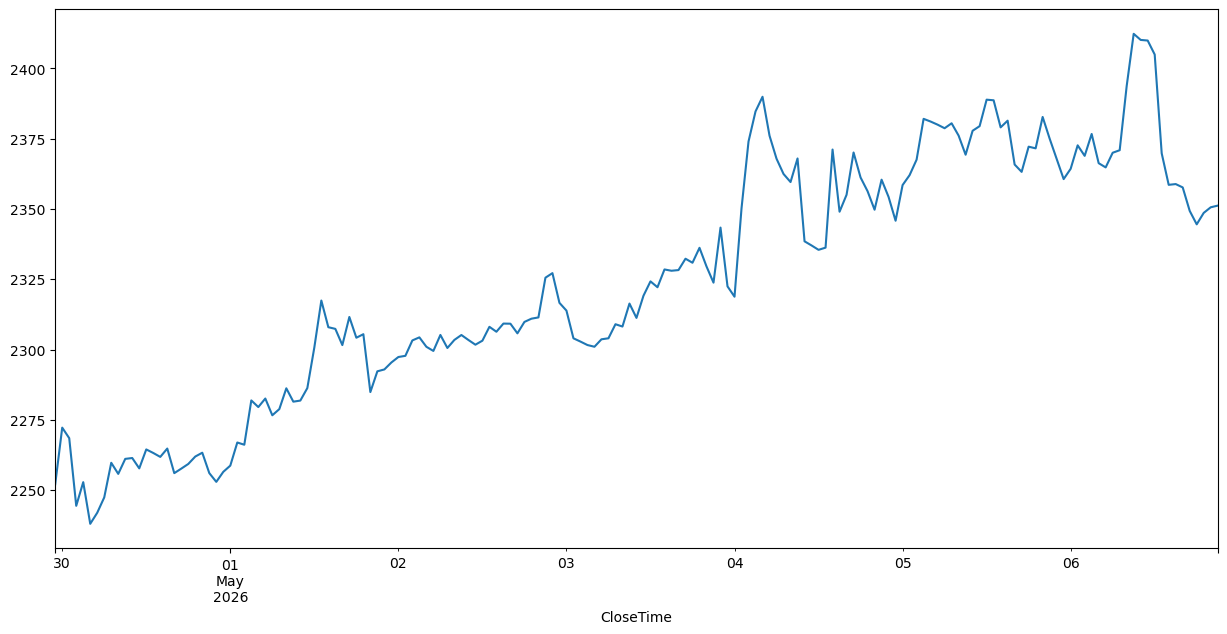

In [34]:
eth['ClosePrice'].plot(figsize=(15, 7))

In [35]:
eth.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-04-29 23:00:00,2257.03,2259.00,2250.00,2252.11,236.491492
2026-04-30 00:00:00,2252.12,2274.00,2249.42,2272.23,744.269713
2026-04-30 01:00:00,2271.44,2277.64,2266.60,2268.48,322.663943
2026-04-30 02:00:00,2268.41,2272.42,2235.55,2244.42,1749.314418
2026-04-30 03:00:00,2244.08,2255.80,2242.91,2252.84,106.197401
